# Lab final

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
image=cv2.imread('road.bmp',cv2.IMREAD_GRAYSCALE).astype(np.float32)

question1: print the size of the image

In [ ]:
print(image.size) 

65536


question 2: log transform

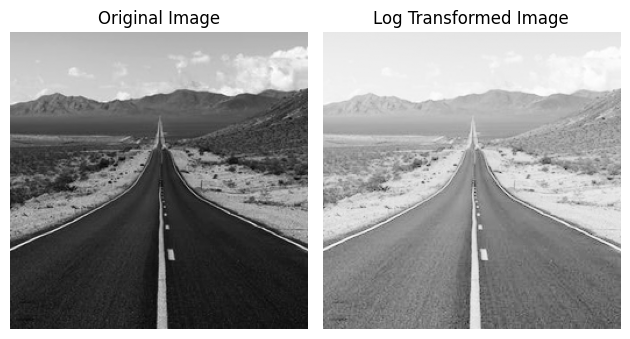

In [29]:
c = 255 / np.log(1+np.max(image))

log_img = np.zeros_like(image)

for i in range(image.shape[0]):
  for j in range(image.shape[1]):
    log_img[i][j] = c * np.log(1 + image[i][j])


plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

question 3: Apply the median filter on the the log-transformation

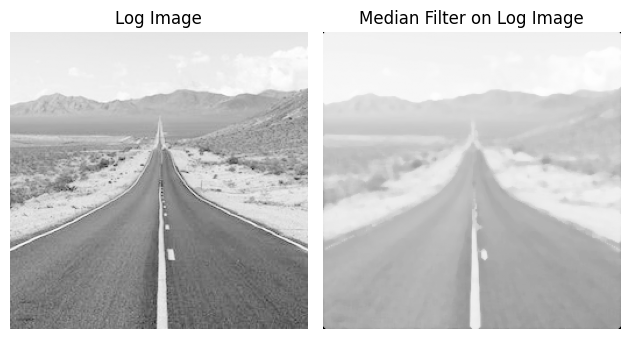

In [ ]:
def median_filter(image, kernel_size=3):

    pad = kernel_size // 2
    img_h, img_w = image.shape

    padded_img = np.pad(image, pad, mode='constant', constant_values=0).astype(np.float32)
    result = np.zeros_like(image)
    for i in range(img_h):
        for j in range(img_w):
            current = padded_img[i:i+kernel_size, j:j+kernel_size]
            current_flat = current.flatten()
            current_sorted = np.sort(current_flat)
            median_value = current_sorted[len(current_sorted)//2] 
            result[i][j] = median_value

    return result.astype(np.uint8)

median_img = median_filter(log_img, 5)


plt.subplot(1, 2, 1)
plt.imshow(log_img, cmap='gray')
plt.title('Log Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(median_img, cmap='gray')
plt.title('Median Filter on Log Image')
plt.axis('off')

plt.tight_layout()
plt.show()

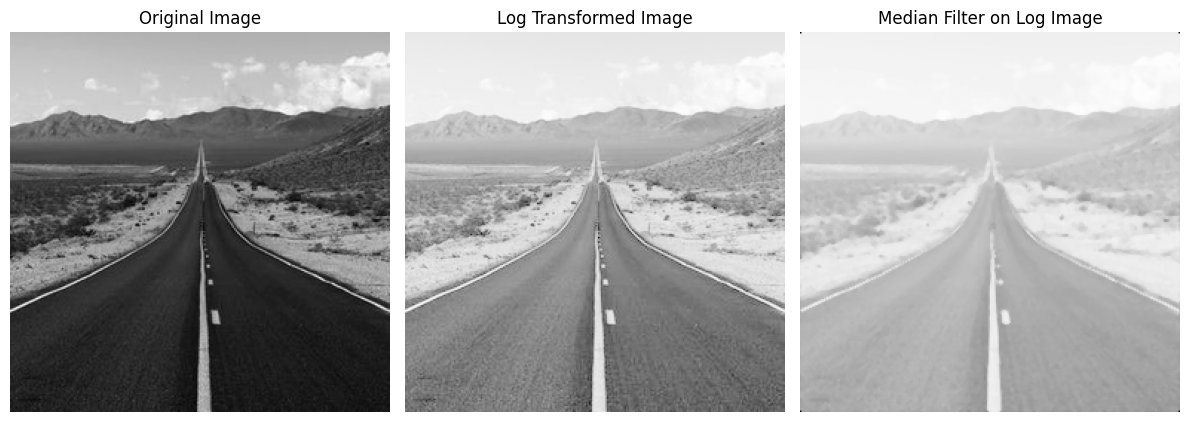

In [28]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(log_img, cmap='gray')
plt.title('Log Transformed Image')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(median_img, cmap='gray')
plt.title('Median Filter on Log Image')
plt.axis('off')
plt.tight_layout()
plt.show()